# Automotive Part Image-Text Matching — Dataset V2

## Final Deep Learning Exam Project

In this project I compare an automotive-part image with a short text description and predict one of three labels:

- **MATCH** — the image and text describe the same part;
- **PARTIAL_MATCH** — the parts are different but belong to the same automotive system;
- **MISMATCH** — the parts belong to different systems.

**Research question:** Can a small model that uses both image and text perform better than image-only, text-only, and non-neural baselines?

This notebook is the executed report. It reads saved validation artifacts. The locked test CSV is not read here.

## 1. Problem and motivation

Online catalogues and automotive warehouses need the product photo and description to agree. A wrong pair can cause a wrong listing or a picking mistake.

The task needs both modalities because every image is paired with examples from all three labels. The project is a course experiment, not a production system. I compare simple baselines with small PyTorch models and check the main leakage risks.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

ROOT = Path.cwd()
DATA = ROOT / "data"
RESULTS = ROOT / "results"

manifest = pd.read_csv(DATA / "image_manifest.csv")
provenance = pd.read_csv(DATA / "dataset_v2_manifest.csv")
train = pd.read_csv(DATA / "train.csv")
validation = pd.read_csv(DATA / "validation.csv")
model_comparison = pd.read_csv(RESULTS / "model_comparison.csv")
predictions = pd.read_csv(RESULTS / "validation_predictions.csv")
main_predictions = pd.read_csv(RESULTS / "multimodal_validation_predictions.csv")
paired = pd.read_csv(RESULTS / "paired_comparisons.csv")
audit = json.loads((RESULTS / "data_audit.json").read_text(encoding="utf-8"))
run_info = json.loads((RESULTS / "run_info.json").read_text(encoding="utf-8"))
verification = json.loads((RESULTS / "verification_summary.json").read_text(encoding="utf-8"))

print(f"Dataset version: {run_info['dataset_version']}")
print(f"Python: {run_info['python_version']} | PyTorch: {run_info['torch_version']}")
print(f"Verification status before this execution: {verification.get('status')}")

Dataset version: 2.0
Python: 3.13.5 | PyTorch: 2.10.0+cpu
Verification status before this execution: PASS


## 2. Data and Dataset V2

Dataset V2 combines:

1. the original Wikimedia Commons photographs;
2. additional real images from the Apache-2.0 **50 Types of Car Parts** Kaggle dataset and Wikimedia Commons;
3. simple synthetic drawings used only for a training ablation.

The importer checks that images are readable, applies EXIF orientation, converts to RGB, resizes selected images to 224×224, calculates hashes, and rejects duplicates. Source and license details are stored in the manifests. The original test images remain locked.

Every image creates six related rows: two for each relation label. The image is therefore the independent evaluation unit.

In [2]:
image_summary = (
    manifest.groupby(["split", "source"])
    .size()
    .rename("independent_images")
    .reset_index()
)
row_summary = pd.DataFrame({
    "split": ["train", "validation"],
    "paired_rows": [len(train), len(validation)],
    "independent_images": [train.image_id.nunique(), validation.image_id.nunique()],
    "unique_descriptions": [train.description.nunique(), validation.description.nunique()],
})

display(image_summary)
display(row_summary)

provider_summary = provenance.groupby(["provider", "assigned_split"]).size().rename("images").reset_index()
display(provider_summary)

,split,source,independent_images
0,test,wikimedia,10
1,train,dataset_v2,50
2,train,generated,50
3,train,wikimedia,50
4,validation,dataset_v2,10
5,validation,wikimedia,10


,split,paired_rows,independent_images,unique_descriptions
0,train,900,150,40
1,validation,120,20,20


,provider,assigned_split,images
0,Kaggle,train,40
1,Kaggle,validation,8
2,Wikimedia Commons,train,10
3,Wikimedia Commons,validation,2


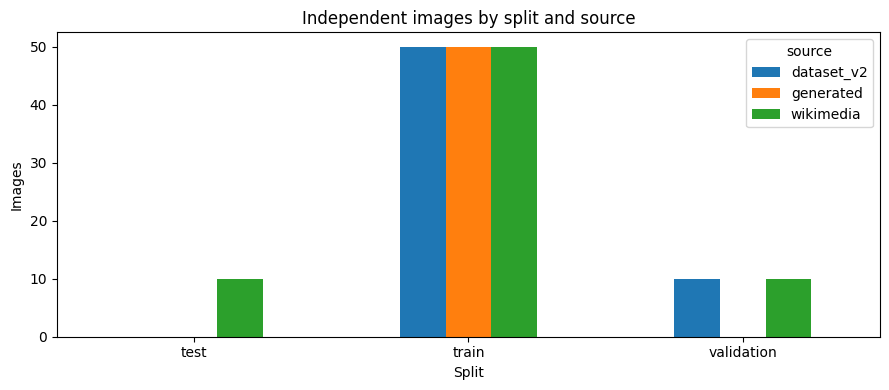

In [3]:
source_plot = image_summary.pivot(index="split", columns="source", values="independent_images").fillna(0)
ax = source_plot.plot(kind="bar", figsize=(9, 4))
ax.set_title("Independent images by split and source")
ax.set_xlabel("Split")
ax.set_ylabel("Images")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 3. Leakage and statistical checks

The project checks IDs, object groups, file paths, exact image hashes, exact captions, and visually similar real images. Alternate views of the same known object stay in one group.

Since six rows come from the same image, treating every row as independent would overstate the sample size. Confidence intervals use complete image groups. Paired model comparisons use an **image-group sign-flip randomization test**.

In [4]:
leakage_checks = pd.Series({
    "part_group_overlap": audit["overlap"]["part_group_overlap"],
    "object_group_overlap": audit["overlap"]["object_group_overlap"],
    "image_id_overlap": audit["overlap"]["image_id_overlap"],
    "image_path_overlap": audit["overlap"]["image_path_overlap"],
    "exact_image_hash_overlap": audit["exact_cross_split_image_hash_overlap"],
    "exact_description_overlap": audit["exact_description_overlap"],
    "suspicious_near_image_pairs": audit["suspicious_real_image_pairs"],
})
display(leakage_checks.to_frame("count"))

assert (leakage_checks == 0).all()
assert audit["test_split_used"] is False
assert audit["test_lock"]["sha256_matches"] is True

,count
part_group_overlap,0
object_group_overlap,0
image_id_overlap,0
image_path_overlap,0
exact_image_hash_overlap,0
exact_description_overlap,0
suspicious_near_image_pairs,0


## 4. Models

I compare four non-neural baselines and four PyTorch models:

- majority baseline;
- text Logistic Regression;
- image Logistic Regression;
- image + text Logistic Regression;
- neural text MLP;
- image-only CNN;
- multimodal CNN + text MLP trained on real images;
- the same multimodal model trained on real and synthetic images.

The multimodal model joins image and text features before the final relation prediction. It also uses image-category and text-category helper losses during training, but only the relation output is scored.

In [5]:
comparison_view = model_comparison[[
    "model", "modality", "training_data", "validation_accuracy", "validation_macro_f1",
    "accuracy_ci_low", "accuracy_ci_high", "correct_predictions", "total_predictions"
]].copy()
display(comparison_view)

,model,modality,training_data,validation_accuracy,validation_macro_f1,accuracy_ci_low,accuracy_ci_high,correct_predictions,total_predictions
0,PyTorch multimodal CNN (real-only training),image + text,100 real train images,0.508333,0.503439,0.341667,0.666667,61,120
1,PyTorch multimodal CNN (real + synthetic train...,image + text,100 real + 50 synthetic train images,0.458333,0.425134,0.325000,0.591667,55,120
2,Image + text Logistic Regression,image + text,all train rows,0.333333,0.166667,0.333333,0.333333,40,120
3,Image pixels + Logistic Regression,image,all train rows,0.333333,0.166667,0.333333,0.333333,40,120
4,Majority baseline,none,all train rows,0.333333,0.166667,0.333333,0.333333,40,120
5,PyTorch CNN image model,image,all train rows,0.333333,0.166667,0.333333,0.333333,40,120
6,PyTorch neural text model,text,all train rows,0.333333,0.166667,0.333333,0.333333,40,120
7,TF-IDF + Logistic Regression,text,all train rows,0.333333,0.166667,0.333333,0.333333,40,120


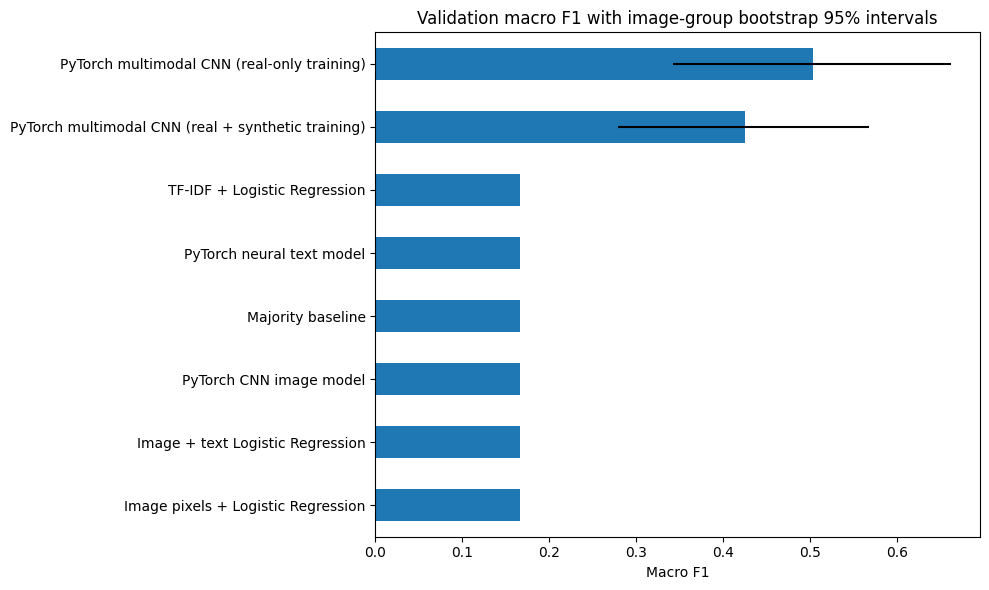

In [6]:
plot_table = model_comparison.sort_values("validation_macro_f1")
errors = np.vstack([
    plot_table["validation_macro_f1"] - plot_table["macro_f1_ci_low"],
    plot_table["macro_f1_ci_high"] - plot_table["validation_macro_f1"],
])
ax = plot_table.plot(
    x="model",
    y="validation_macro_f1",
    kind="barh",
    xerr=errors,
    legend=False,
    figsize=(10, 6),
)
ax.set_title("Validation macro F1 with image-group bootstrap 95% intervals")
ax.set_xlabel("Macro F1")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Main-model errors

The confusion matrix and class report use predictions from the real-only multimodal model. The labels are balanced, but the 120 rows come from only 20 independent validation images. This smaller image count is the important sample size.

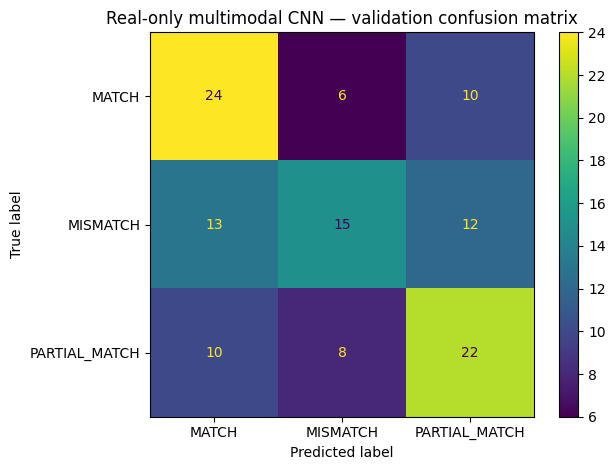

,precision,recall,f1-score,support
MATCH,0.510638,0.600000,0.551724,40.000000
MISMATCH,0.517241,0.375000,0.434783,40.000000
PARTIAL_MATCH,0.500000,0.550000,0.523810,40.000000
accuracy,0.508333,0.508333,0.508333,0.508333
macro avg,0.509293,0.508333,0.503439,120.000000
weighted avg,0.509293,0.508333,0.503439,120.000000


In [7]:
labels = ["MATCH", "MISMATCH", "PARTIAL_MATCH"]
cm = confusion_matrix(
    main_predictions["true_label"],
    main_predictions["predicted_label"],
    labels=labels,
)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(values_format="d")
plt.title("Real-only multimodal CNN — validation confusion matrix")
plt.tight_layout()
plt.show()

report = pd.DataFrame(
    classification_report(
        main_predictions["true_label"],
        main_predictions["predicted_label"],
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
).T
display(report)

,part_category,samples,correct,accuracy,macro_f1
0,air_filter,12,5,0.416667,0.444444
1,alternator,12,5,0.416667,0.414815
2,brake_disc,12,10,0.833333,0.814815
3,brake_pad,12,6,0.500000,0.518519
4,coil_spring,12,2,0.166667,0.133333
5,headlight,12,3,0.250000,0.216450
6,oil_filter,12,0,0.000000,0.000000
7,shock_absorber,12,10,0.833333,0.814815
8,starter,12,10,0.833333,0.814815
9,taillight,12,10,0.833333,0.822222


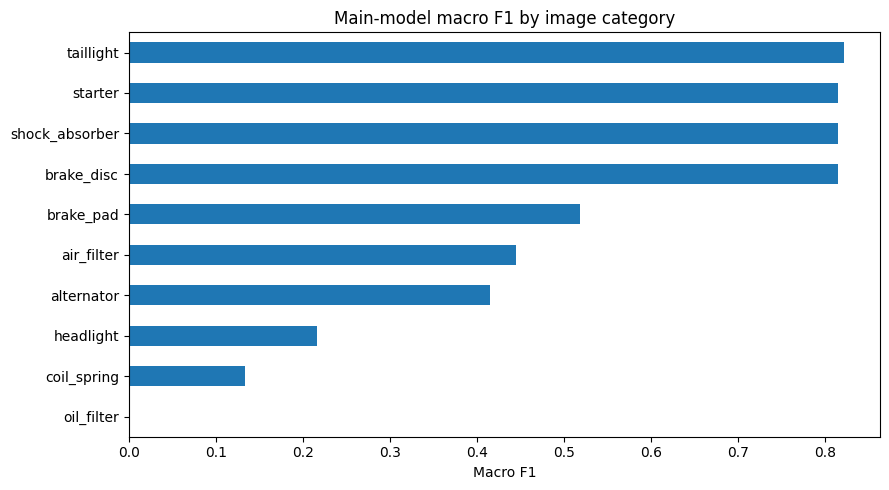

In [8]:
per_category = pd.read_csv(RESULTS / "multimodal_per_category.csv")
display(per_category)

ax = per_category.sort_values("macro_f1").plot(
    x="part_category", y="macro_f1", kind="barh", legend=False, figsize=(9, 5)
)
ax.set_title("Main-model macro F1 by image category")
ax.set_xlabel("Macro F1")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [9]:
errors = main_predictions.loc[
    ~main_predictions["is_correct"],
    ["part_category", "text_category", "description", "true_label", "predicted_label", "image_path"],
]
display(errors.head(15))
print(f"Errors: {len(errors)} of {len(main_predictions)} paired rows")

,part_category,text_category,description,true_label,predicted_label,image_path
0,air_filter,air_filter,The pictured part is the engine air filter; it...,MATCH,MISMATCH,data/images/dataset_v2/air_filter/dataset_v2_a...
1,air_filter,oil_filter,The pictured part is the engine oil filter; it...,PARTIAL_MATCH,MISMATCH,data/images/dataset_v2/air_filter/dataset_v2_a...
2,air_filter,alternator,The pictured part is the automotive alternator...,MISMATCH,PARTIAL_MATCH,data/images/dataset_v2/air_filter/dataset_v2_a...
3,air_filter,air_filter,This engine air filter belongs to the air-inta...,MATCH,MISMATCH,data/images/dataset_v2/air_filter/dataset_v2_a...
4,air_filter,oil_filter,This engine oil filter belongs to the engine l...,PARTIAL_MATCH,MISMATCH,data/images/dataset_v2/air_filter/dataset_v2_a...
5,air_filter,brake_pad,This automotive brake pad belongs to the disc-...,MISMATCH,PARTIAL_MATCH,data/images/dataset_v2/air_filter/dataset_v2_a...
8,air_filter,brake_disc,This brake disc or rotor belongs to the disc-b...,MISMATCH,PARTIAL_MATCH,data/images/wikimedia/air_filter/commons_air_f...
12,alternator,alternator,The pictured part is the automotive alternator...,MATCH,PARTIAL_MATCH,data/images/dataset_v2/alternator/dataset_v2_a...
13,alternator,starter,The pictured part is the automotive starter mo...,PARTIAL_MATCH,MATCH,data/images/dataset_v2/alternator/dataset_v2_a...
14,alternator,brake_disc,The pictured part is the brake disc or rotor; ...,MISMATCH,MATCH,data/images/dataset_v2/alternator/dataset_v2_a...


Errors: 59 of 120 paired rows


## 6. Paired comparison and synthetic-data ablation

The same validation images are used for each model. I compare correctness by complete image groups instead of separate rows. The p-value is only one part of the result, so I also report confidence intervals, class behaviour, and the size of the validation set.

In [10]:
display(paired)

display(model_comparison.loc[
    model_comparison["model_slug"].isin([
        "torch_multimodal_real_only",
        "torch_multimodal_real_plus_synthetic",
    ]),
    ["model", "validation_accuracy", "validation_macro_f1", "accuracy_ci_low", "accuracy_ci_high"],
])

,left_model_slug,right_model_slug,method,group_column,independent_groups,paired_rows,left_correct_total,right_correct_total,observed_correct_difference,observed_accuracy_difference,left_better_groups,right_better_groups,tied_groups,left_correct_right_wrong_rows,left_wrong_right_correct_rows,row_discordant_predictions,randomization_assignments,randomization_seed,grouped_two_sided_p_value
0,torch_multimodal_real_only,image_text_logistic_regression,exact_image_group_sign_flip,image_id,20,120,61,40,21,0.175,12,8,0,37,16,53,1048576,NaN,0.072876
1,torch_multimodal_real_only,torch_multimodal_real_plus_synthetic,exact_image_group_sign_flip,image_id,20,120,61,55,6,0.050,9,4,7,15,9,24,1048576,NaN,0.430420


,model,validation_accuracy,validation_macro_f1,accuracy_ci_low,accuracy_ci_high
0,PyTorch multimodal CNN (real-only training),0.508333,0.503439,0.341667,0.666667
1,PyTorch multimodal CNN (real + synthetic train...,0.458333,0.425134,0.325000,0.591667


## 7. Previous research and data sources

The project is much smaller than established vision-language research, but it uses ideas from:

1. Faghri et al., **VSE++: Improving Visual-Semantic Embeddings with Hard Negatives**, BMVC 2018;
2. Li et al., **VisualBERT: A Simple and Performant Baseline for Vision and Language**, 2019;
3. Radford et al., **Learning Transferable Visual Models From Natural Language Supervision (CLIP)**, ICML 2021;
4. He et al., **Deep Residual Learning for Image Recognition**, CVPR 2016.

The additional automotive images come from the Apache-2.0 **50 Types of Car Parts** Kaggle dataset and open-license Wikimedia Commons files. Their source and license information is stored in the project manifests.

The results are not directly comparable with large pretrained benchmarks. This is a small supervised relation-classification experiment for the course.

## 8. Limitations

- Validation is used for early stopping and model choice, so it is not a final unbiased test result.
- The final test remains locked until every modelling decision is fixed.
- Several text pairs share one image, so image-group statistics are required.
- Part names appear in the descriptions. The task is relation classification, not open-vocabulary language understanding.
- Public datasets can contain imperfect labels or source-specific visual patterns.
- Synthetic drawings are simple templates and are used only as a training ablation.

In [11]:
main = model_comparison.set_index("model_slug").loc["torch_multimodal_real_only"]
baseline = model_comparison.set_index("model_slug").loc["image_text_logistic_regression"]
pair = paired.loc[paired["right_model_slug"].eq("image_text_logistic_regression")].iloc[0]

summary = f'''
## 9. Conclusion

The real-only multimodal model achieved **{main.validation_accuracy:.4f} validation accuracy** and **{main.validation_macro_f1:.4f} macro F1** ({int(main.correct_predictions)}/{int(main.total_predictions)} correct rows). The image + text Logistic Regression baseline achieved **{baseline.validation_accuracy:.4f} accuracy** and **{baseline.validation_macro_f1:.4f} macro F1**.

The paired comparison used **{int(pair.independent_groups)} independent images** and gave **p = {pair.grouped_two_sided_p_value:.6f}**. The neural model performed better in this validation run, but the sample is still small and the result is not proof that it will always be better.

Dataset V2 adds more independent real photographs, more varied captions, duplicate checks, and image-group statistics. The synthetic drawings did not improve the selected model. The final test split was not used.
'''
display(Markdown(summary))


## 9. Conclusion

The real-only multimodal model achieved **0.5083 validation accuracy** and **0.5034 macro F1** (61/120 correct rows). The image + text Logistic Regression baseline achieved **0.3333 accuracy** and **0.1667 macro F1**.

The paired comparison used **20 independent images** and gave **p = 0.072876**. The neural model performed better in this validation run, but the sample is still small and the result is not proof that it will always be better.

Dataset V2 adds more independent real photographs, more varied captions, duplicate checks, and image-group statistics. The synthetic drawings did not improve the selected model. The final test split was not used.


In [12]:
assert run_info["test_split_used"] is False
assert verification.get("status") in {"PASS", "PENDING_NOTEBOOK_REEXECUTION"}
print("Notebook integrity checks passed. The locked test split was not read.")

Notebook integrity checks passed. The locked test split was not read.
